In [3]:
from google.colab import drive
import os
import shutil
import random
import kagglehub
from tqdm import tqdm

drive.mount('/content/drive')

def create_subset_colab(source_dir, target_dir, num_subjects=50, images_per_subject=15):
    if not os.path.exists(target_dir):
        os.makedirs(target_dir)

    # Scansiona le cartelle (ID dei soggetti)
    subjects = [d for d in os.listdir(source_dir) if os.path.isdir(os.path.join(source_dir, d))]

    if not subjects:
        print(f"ERRORE: Nessuna cartella trovata in {source_dir}. Controlla la struttura del dataset.")
        return

    selected_subjects = random.sample(subjects, min(num_subjects, len(subjects)))
    print(f"Copia di {len(selected_subjects)} soggetti in '{target_dir}'...")

    for subject in tqdm(selected_subjects):
        subj_source_path = os.path.join(source_dir, subject)
        subj_target_path = os.path.join(target_dir, subject)

        if not os.path.exists(subj_target_path):
            os.makedirs(subj_target_path)

        images = [f for f in os.listdir(subj_source_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        selected_images = random.sample(images, min(images_per_subject, len(images)))

        for img in selected_images:
            shutil.copy(os.path.join(subj_source_path, img), os.path.join(subj_target_path, img))


print("Inizio download CASIA dataset (storage volatile)...")
download_path = kagglehub.dataset_download("cybersimar08/casia-face-dataset")

# 2. RICERCA DINAMICA DELLA ROOT FOLDER

subdirs = [os.path.join(download_path, d) for d in os.listdir(download_path) if os.path.isdir(os.path.join(download_path, d))]
if len(subdirs) == 1 and not any(f.endswith('.jpg') for f in os.listdir(download_path)):
    source_folder = subdirs[0] # Entra nella sottocartella (es. "CASIA-WebFace")
else:
    source_folder = download_path # Le identità sono già nella root

print(f"Cartella sorgente identificata: {source_folder}")

local_target_folder = "/content/local_casia_subset"

NUM_SOGGETTI = 500
IMG_PER_SOGGETTO = 100

# Esecuzione I/O locale
create_subset_colab(source_folder, local_target_folder, num_subjects=NUM_SOGGETTI, images_per_subject=IMG_PER_SOGGETTO)

print("\nCompressione del subset in corso...")
zip_path = "/content/casia_subset"
shutil.make_archive(zip_path, 'zip', local_target_folder)

drive_destination = "/content/drive/MyDrive/DeepLearning_Project/casia_subset.zip"

print(f"Trasferimento del file zip su Drive in: {drive_destination} ...")
# Rimuove il vecchio zip se esiste per evitare conflitti
if os.path.exists(drive_destination):
    os.remove(drive_destination)

shutil.copy(zip_path + ".zip", drive_destination)

Mounted at /content/drive
Inizio download CASIA dataset (storage volatile)...


100%|██████████| 52.2M/52.2M [00:00<00:00, 70.0MB/s]

Extracting files...


Cartella sorgente identificata: /root/.cache/kagglehub/datasets/cybersimar08/casia-face-dataset/versions/1/casia dataset
Copia di 200 soggetti in '/content/local_casia_subset'...


100%|██████████| 200/200 [00:01<00:00, 125.29it/s]



Compressione del subset in corso...
Trasferimento del file zip su Drive in: /content/drive/MyDrive/DeepLearning_Project/casia_subset.zip ...


'/content/drive/MyDrive/DeepLearning_Project/casia_subset.zip'

In [4]:
import os
import shutil
import torch
import random
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from PIL import Image

zip_path = "/content/drive/MyDrive/DeepLearning_Project/casia_subset.zip"
extract_dir = "/content/casia_unzipped"

if not os.path.exists(extract_dir):
    print("Decompressione dell'archivio nel disco NVMe locale in corso...")
    shutil.unpack_archive(zip_path, extract_dir)
    print("Decompressione completata!")

# DATASET REFACTORING
class FaceDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, self.labels[idx]

# SPLIT: Open-Set split sulle identità
all_identities = sorted([d for d in os.listdir(extract_dir) if os.path.isdir(os.path.join(extract_dir, d))])

random.seed(42)
shuffled_identities = all_identities.copy()
random.shuffle(shuffled_identities)

# Dividiamo le identità (es. 80% train, 20% test)
split_idx = int(len(shuffled_identities) * 0.8)
train_identities = shuffled_identities[:split_idx]
test_identities = shuffled_identities[split_idx:]

# Creiamo dizionari per mappare le identità a label numeriche.
# Per il test set, queste label serviranno solo per il calcolo della mAP/KNN,
# non per la classificazione Cross-Entropy.
train_id_to_label = {identity: idx for idx, identity in enumerate(train_identities)}
test_id_to_label = {identity: idx for idx, identity in enumerate(test_identities)}

train_paths, train_labels = [], []
test_paths, test_labels = [], []

# Popoliamo il Train Set
for identity in train_identities:
    subj_dir = os.path.join(extract_dir, identity)
    images = [os.path.join(subj_dir, f) for f in os.listdir(subj_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    train_paths.extend(images)
    train_labels.extend([train_id_to_label[identity]] * len(images))

# Popoliamo il Test Set
for identity in test_identities:
    subj_dir = os.path.join(extract_dir, identity)
    images = [os.path.join(subj_dir, f) for f in os.listdir(subj_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    test_paths.extend(images)
    test_labels.extend([test_id_to_label[identity]] * len(images))

print(f"Identità in Train: {len(train_identities)} | Identità in Test: {len(test_identities)}")
print(f"Immagini di Train: {len(train_paths)} | Immagini di Test: {len(test_paths)}")

# TRASFORMAZIONI
train_transform = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# INIZIALIZZAZIONE LOADER
train_dataset = FaceDataset(train_paths, train_labels, transform=train_transform)
test_dataset = FaceDataset(test_paths, test_labels, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

Decompressione dell'archivio nel disco NVMe locale in corso...
Decompressione completata!
Identità in Train: 160 | Identità in Test: 40
Immagini di Train: 16000 | Immagini di Test: 4000


In [5]:
import torchvision.models as models
import torch.nn as nn

# ResNet18 con i pesi pre-addestrati
baseline_model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Sostituiamo l'ultimo layer.
in_features = baseline_model.fc.in_features

num_train_classes = len(train_identities)
baseline_model.fc = nn.Linear(in_features, num_train_classes)

# Spostiamo il modello su GPU se disponibile
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
baseline_model = baseline_model.to(device)
print(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 116MB/s]


cuda


In [6]:
import torch.optim as optim
from tqdm import tqdm

# Iperparametri
EPOCHS = 15
LEARNING_RATE = 1e-3

# Loss e Ottimizzatore
criterion = nn.CrossEntropyLoss()
# Ottimizziamo tutti i pesi della ResNet per estrarre buone feature, non solo l'ultimo layer
optimizer = optim.Adam(baseline_model.parameters(), lr=LEARNING_RATE)

# (Opzionale ma consigliato) Uno scheduler per ridurre il LR e stabilizzare la convergenza
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

print("Inizio addestramento della Baseline (Classificazione)...")

baseline_model.train()

for epoch in range(EPOCHS):
    running_loss = 0.0
    correct = 0
    total = 0

    # Usiamo tqdm per una barra di caricamento visivamente pulita
    loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{EPOCHS}]")

    for inputs, labels in loop:
        inputs, labels = inputs.to(device), labels.to(device)

        # 1. Azzeramento dei gradienti
        optimizer.zero_grad()

        # 2. Forward pass
        outputs = baseline_model(inputs)

        # 3. Calcolo della Loss
        loss = criterion(outputs, labels)

        # 4. Backward pass e Ottimizzazione
        loss.backward()
        optimizer.step()

        # Statistiche
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        # Aggiornamento barra tqdm
        loop.set_postfix(loss=loss.item(), acc=100. * correct / total)

    scheduler.step()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100. * correct / total
    print(f"Epoch [{epoch+1}/{EPOCHS}] Completata -> Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.2f}%")

Inizio addestramento della Baseline (Classificazione)...


Epoch [1/15]: 100%|██████████| 500/500 [00:58<00:00,  8.53it/s, acc=14, loss=2.53]


Epoch [1/15] Completata -> Train Loss: 3.9146 | Train Acc: 13.99%


Epoch [2/15]: 100%|██████████| 500/500 [00:59<00:00,  8.45it/s, acc=45.9, loss=1.64]


Epoch [2/15] Completata -> Train Loss: 2.1866 | Train Acc: 45.89%


...

Epoch [13/15] Completata -> Train Loss: 0.0609 | Train Acc: 99.33%


Epoch [14/15]: 100%|██████████| 500/500 [00:58<00:00,  8.54it/s, acc=99.4, loss=0.0148]


Epoch [14/15] Completata -> Train Loss: 0.0573 | Train Acc: 99.41%


Epoch [15/15]: 100%|██████████| 500/500 [00:58<00:00,  8.52it/s, acc=99.5, loss=0.0375]

Epoch [15/15] Completata -> Train Loss: 0.0535 | Train Acc: 99.50%


In [7]:
import torch.nn as nn
import numpy as np
from tqdm import tqdm

# 1. Rimuoviamo il classificatore finale per ottenere lo spazio latente
baseline_model.fc = nn.Identity()
baseline_model.eval()

def extract_embeddings(dataloader, model, device):
    embeddings = []
    labels_list = []

    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc="Estrazione Embedding"):
            inputs = inputs.to(device)

            # Estraiamo le feature
            features = model(inputs)

            # Normalizzazione L2: mappa i vettori su un'ipersfera unitaria
            features = torch.nn.functional.normalize(features, p=2, dim=1)

            embeddings.append(features.cpu())
            labels_list.append(labels.cpu())

    # Concateniamo tutti i batch in un unico tensore
    return torch.cat(embeddings).numpy(), torch.cat(labels_list).numpy()

print("Estrazione embedding del Test Set...")
test_embeddings, test_labels_array = extract_embeddings(test_loader, baseline_model, device)
print(f"Shape degli embedding estratti: {test_embeddings.shape}")

Estrazione embedding del Test Set...


Estrazione Embedding: 100%|██████████| 125/125 [00:10<00:00, 12.17it/s]


Shape degli embedding estratti: (4000, 512)


In [8]:
from sklearn.neighbors import NearestNeighbors

def evaluate_retrieval(embeddings, labels, k_list=[1, 5, 10]):
    print("\nCalcolo delle metriche di Retrieval (KNN)...")

    # Inizializziamo il KNN usando la distanza del coseno
    max_k = max(k_list)
    # Cerchiamo max_k + 1 vicini, perché il primo risultato sarà sempre l'immagine stessa (distanza 0)
    knn = NearestNeighbors(n_neighbors=max_k + 1, metric='cosine')
    knn.fit(embeddings)

    distances, indices = knn.kneighbors(embeddings)

    indices = indices[:, 1:]

    rank_metrics = {k: 0.0 for k in k_list}
    mAP = 0.0

    num_queries = len(labels)

    for i in range(num_queries):
        query_label = labels[i]
        retrieved_labels = labels[indices[i]]

        # Identifichiamo i match corretti
        matches = (retrieved_labels == query_label).astype(int)

        # Calcolo Rank-K
        for k in k_list:
            if matches[:k].sum() > 0:
                rank_metrics[k] += 1

        # Calcolo Average Precision per la singola query
        total_relevant = (labels == query_label).sum() - 1 # -1 per la query stessa

        if total_relevant > 0:
            precision_at_i = 0.0
            correct_hits = 0
            for rank, is_match in enumerate(matches):
                if is_match:
                    correct_hits += 1
                    precision_at_i += correct_hits / (rank + 1)

            mAP += precision_at_i / total_relevant

    # Medie
    mAP /= num_queries
    for k in k_list:
        rank_metrics[k] = (rank_metrics[k] / num_queries) * 100

    print("-" * 30)
    print(f"Mean Average Precision (mAP): {mAP:.4f}")
    for k in k_list:
        print(f"Rank-{k} Accuracy: {rank_metrics[k]:.2f}%")
    print("-" * 30)

evaluate_retrieval(test_embeddings, test_labels_array)


Calcolo delle metriche di Retrieval (KNN)...
------------------------------
Mean Average Precision (mAP): 0.0592
Rank-1 Accuracy: 74.33%
Rank-5 Accuracy: 88.58%
Rank-10 Accuracy: 92.77%
------------------------------


In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data.sampler import Sampler
import random
from collections import defaultdict

# P-K Sampler
class PKSampler(Sampler):
    def __init__(self, labels, p_classes, k_samples):
        self.labels = labels
        self.p_classes = p_classes
        self.k_samples = k_samples

        self.label_to_indices = defaultdict(list)
        for idx, label in enumerate(labels):
            self.label_to_indices[label].append(idx)

        self.unique_labels = list(self.label_to_indices.keys())

    def __iter__(self):
        all_batches = []
        num_batches = len(self.labels) // (self.p_classes * self.k_samples)
        for _ in range(num_batches):
            batch_indices = []
            selected_classes = random.sample(self.unique_labels, self.p_classes)
            for label in selected_classes:
                indices = self.label_to_indices[label]
                batch_indices.extend(
                    random.sample(indices, self.k_samples)
                    if len(indices) >= self.k_samples
                    else random.choices(indices, k=self.k_samples)
                )
            all_batches.extend(batch_indices)
        return iter(all_batches)

    def __len__(self):   # ← indentato dentro la classe
        return (len(self.labels) // (self.p_classes * self.k_samples)) * self.p_classes * self.k_samples
# ==========================================
# 2. Hard Triplet Loss (Vectorized)
# ==========================================
class OnlineHardTripletLoss(nn.Module):
    def __init__(self, margin=0.5):
        super().__init__()
        self.margin = margin

    def forward(self, embeddings, labels):

        dot_product = torch.matmul(embeddings, embeddings.t())
        square_norm = torch.diag(dot_product)
        distances = square_norm.unsqueeze(0) - 2.0 * dot_product + square_norm.unsqueeze(1)

        distances = torch.clamp(distances, min=0.0)
        distances = torch.sqrt(distances + 1e-16)

        # Maschere logiche
        labels_equal = labels.unsqueeze(0) == labels.unsqueeze(1)

        # HARD POSITIVE
        mask_positive = labels_equal.float()
        mask_positive.fill_diagonal_(0) # Ignora l'anchor con se stesso
        hardest_positive_dist = (distances * mask_positive).max(dim=1)[0]

        # HARD NEGATIVE
        # Aggiungiamo il massimo globale alle distanze positive, in modo che min() estragga solo i negativi
        max_dist = distances.max()
        distances_neg = distances + (labels_equal.float() * max_dist)
        hardest_negative_dist = distances_neg.min(dim=1)[0]

        # Calcolo della Loss effettiva con il margine
        loss = F.relu(hardest_positive_dist - hardest_negative_dist + self.margin)

        return loss.mean()

# 3. Setup del DataLoader per il Metric Learning
P_CLASSES = 8   # Identità distinte per batch
K_SAMPLES = 4   # Immagini per identità (Batch Size totale = 32)

sampler = PKSampler(train_labels, p_classes=P_CLASSES, k_samples=K_SAMPLES)

metric_train_loader = DataLoader(
    train_dataset,
    batch_size=P_CLASSES * K_SAMPLES,
    sampler=sampler,
    num_workers=2,
    drop_last=True
)

print(f"PKSampler inizializzato! Batch Size: {P_CLASSES * K_SAMPLES}")

PKSampler inizializzato! Batch Size: 32


In [10]:
import torch.optim as optim
from tqdm import tqdm
import torch.nn.functional as F

# Congelamento del Backbone Inferiore
# Blocchiamo tutto tranne gli ultimi due blocchi convoluzionali (layer3 e layer4)
for name, param in baseline_model.named_parameters():
    if "layer3" in name or "layer4" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

# Iperparametri smussati
MARGIN = 0.5
LEARNING_RATE_METRIC = 1e-4
EPOCHS_METRIC = 15

metric_criterion = OnlineHardTripletLoss(margin=MARGIN)

# Ottimizziamo SOLO i parametri che richiedono gradiente
metric_optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, baseline_model.parameters()),
    lr=LEARNING_RATE_METRIC
)

print("Inizio addestramento Metric Learning (Fine-Tuning Stabilizzato)...")

baseline_model.train()

for epoch in range(EPOCHS_METRIC):
    running_loss = 0.0

    loop = tqdm(metric_train_loader, desc=f"Metric Epoch [{epoch+1}/{EPOCHS_METRIC}]")

    for inputs, labels in loop:
        inputs, labels = inputs.to(device), labels.to(device)

        metric_optimizer.zero_grad()

        with torch.set_grad_enabled(True):
            features = baseline_model(inputs)
            features = F.normalize(features, p=2, dim=1)

            loss = metric_criterion(features, labels)

            loss.backward()
            metric_optimizer.step()

        running_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    epoch_loss = running_loss / len(metric_train_loader)
    print(f"Metric Epoch [{epoch+1}/{EPOCHS_METRIC}] Completata -> Train Loss: {epoch_loss:.4f}")

# Valutazione finale
print("\nEstrazione nuovi embedding stabilizzati...")
metric_embeddings, metric_labels_array = extract_embeddings(test_loader, baseline_model, device)

print("\n--- RISULTATI DOPO METRIC LEARNING STABILIZZATO ---")
evaluate_retrieval(metric_embeddings, metric_labels_array)

Inizio addestramento Metric Learning (Fine-Tuning Stabilizzato)...


Metric Epoch [1/15]: 100%|██████████| 500/500 [00:42<00:00, 11.77it/s, loss=0.371]


Metric Epoch [1/15] Completata -> Train Loss: 0.3618


Metric Epoch [2/15]: 100%|██████████| 500/500 [00:41<00:00, 11.94it/s, loss=0.249]


Metric Epoch [2/15] Completata -> Train Loss: 0.3301


...

Metric Epoch [14/15] Completata -> Train Loss: 0.0711


Metric Epoch [15/15]: 100%|██████████| 500/500 [00:43<00:00, 11.57it/s, loss=0.0407]


Metric Epoch [15/15] Completata -> Train Loss: 0.0618

Estrazione nuovi embedding stabilizzati...


Estrazione Embedding: 100%|██████████| 125/125 [00:10<00:00, 11.72it/s]



--- RISULTATI DOPO METRIC LEARNING STABILIZZATO ---

Calcolo delle metriche di Retrieval (KNN)...
------------------------------
Mean Average Precision (mAP): 0.0063
Rank-1 Accuracy: 21.02%
Rank-5 Accuracy: 43.75%
Rank-10 Accuracy: 58.53%
------------------------------


Calcolo t-SNE in corso (potrebbe richiedere qualche decina di secondi)...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


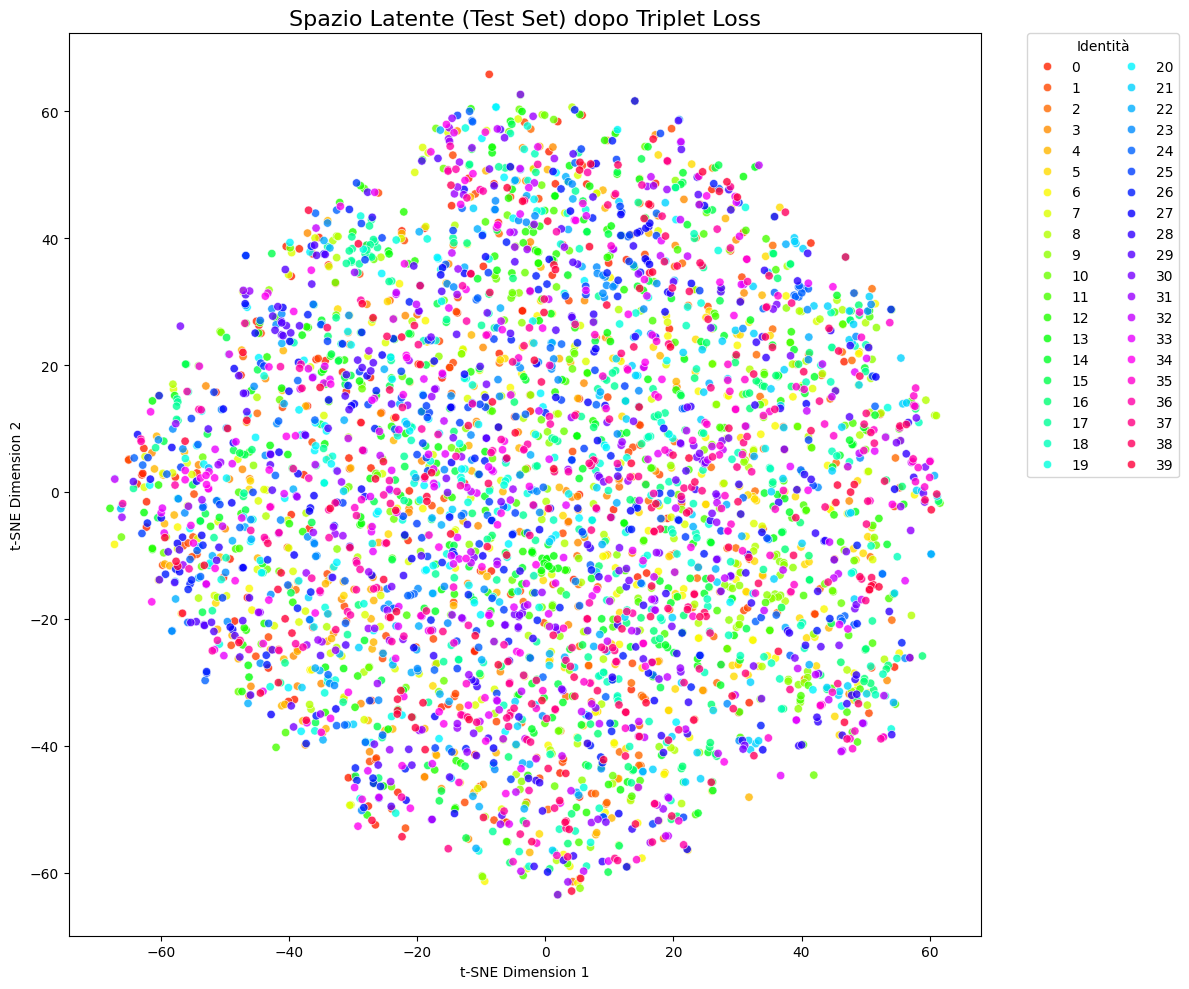

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

def plot_tsne(embeddings, labels, title="t-SNE Projection of Face Embeddings"):
    print("Calcolo t-SNE in corso (potrebbe richiedere qualche decina di secondi)...")

    # Riduciamo la dimensionalità a 2D
    tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
    embeddings_2d = tsne.fit_transform(embeddings)

    plt.figure(figsize=(12, 10))
    sns.scatterplot(
        x=embeddings_2d[:, 0],
        y=embeddings_2d[:, 1],
        hue=labels,
        palette=sns.color_palette("hsv", len(np.unique(labels))),
        legend="full",
        alpha=0.8
    )
    plt.title(title, fontsize=16)
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    # Nascondiamo la legenda se ci sono troppe identità
    plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., title="Identità", ncol=2)
    plt.tight_layout()
    plt.show()

# Eseguiamo il plot sui nuovi embedding
plot_tsne(metric_embeddings, metric_labels_array, title="Spazio Latente (Test Set) dopo Triplet Loss")